# Introduction to Machine Learning (CSCI-UA.473)

### Programming Assignment 4 (Total: 100 points)
#### Due: December 12, 2025 at 11:59PM


#### Name: (Ruixiang Zhu)
#### Email: (rz2718@nyu.edu)

## Summary and Assignment Requirements
This assigment consists broadly of two parts, Dimensionality Reduction and Clustering Methods. The code has several missing pieces which you need to be complete(these are marked by '...' in the code).

**Important:** All required libraries and functions have already been imported. You *may not import anything new*. Unless a task states otherwise, use only the libraries that are already provided.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import fashion_mnist
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score

**Dataset** \
We will be using the Fashion MNIST dataset, which is a dataset of clothing item images—consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes. Fashion-MNIST serves as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms. It shares the same image size and structure of training and testing splits.

In [2]:
LABEL_MAP = {
    0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
}
import numpy as np

def load_fashion_mnist_data(num_samples=None):
    """
    Loads Fashion-MNIST using Keras (robust against SSL errors).

    Args:
        num_samples (int, optional): If provided, returns a random subset of this size.
                                     If None, returns the full dataset (70,000 images).

    Returns:
        X (np.array): Flattened feature matrix of shape (N, 784).
        y (np.array): Label vector of shape (N,).
    """
    print("Loading Fashion-MNIST via TensorFlow/Keras...")

    # 1. Load data from Keras (downloads to ~/.keras/datasets/ if needed)
    (x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

    # 2. Combine Train and Test splits into one big pool
    X = np.concatenate([x_train, x_test])
    y = np.concatenate([y_train, y_test])

    # 3. Flatten the images: (N, 28, 28) -> (N, 784)
    X = X.reshape(X.shape[0], -1)

    # 4. Subset logic
    if num_samples is not None and num_samples < X.shape[0]:
        print(f"   > Subsetting to {num_samples} random samples...")
        np.random.seed(42)  # Ensure students get the same subset every time
        indices = np.random.choice(X.shape[0], num_samples, replace=False)
        X = X[indices]
        y = y[indices]

    # 5. Convert to float32 (Scikit-learn prefers floats for PCA/Scaling)
    X = X.astype(np.float32)

    print(f"   > Data Loaded. Shape: {X.shape}")
    return X, y

### Part 1 : Linear Methods (30 points)
Understand the difference between maximizing variance (unsupervised) and maximizing class separation (supervised).

**Task 1.1:** PCA from Scratch (20 points)

- Implement Principal Component Analysis WITHOUT using sklearn.decomposition (you may use numpy.linalg).

- Preprocess the features
- Implement the first version with solver 'eigen' by computing the Covariance Matrix and performing the eigendecomposition.

- Implement the second version with solver 'svd' by using Singular Value Decomposition (SVD) without computing the covariance matrix.

- Visual: Plot the "Cumulative Explained Variance Ratio" (on y-axis) with  Number of Components (on x-axis).

- Reconstruction: Visualize the "Eigen-clothing" (the top eigenvectors reshaped as images). Show the reconstruction of an original image using only the top 20 components.


**Task 1.2:** The Supervised Contrast (LDA) (5 points)

- Implementation: Use Linear Discriminant Analysis (LDA), also known as Fisher Discriminant Analysis, on the dataset (using the provided labels just for this training step). You may directly use the library implementation LDA imported above.

- Comparison: Project the subset of data used to fit the previous tasks, onto a 2D plane using your top-2 PCA and LDA components.


**Analysis Question:** (5 points)
- Why does the LDA projection look significantly more separated than the PCA projection?
- In what scenario would one prefer using PCA over LDA?

Loading Fashion-MNIST via TensorFlow/Keras...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
   > Subsetting to 2000 random samples...
   > Data Loaded. Shape: (2000, 784)

--- Running PCA From Scratch ---


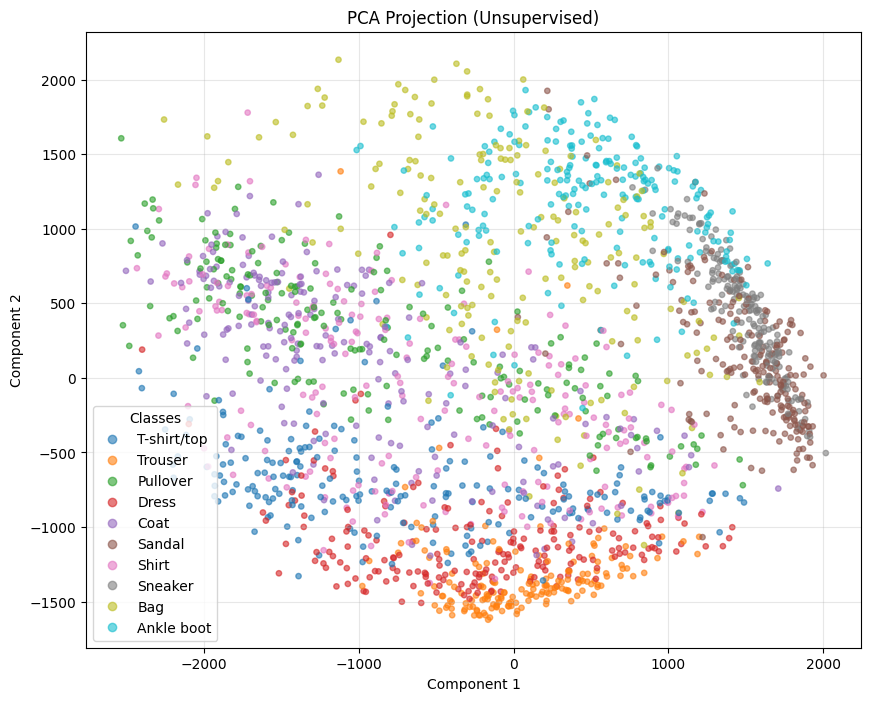

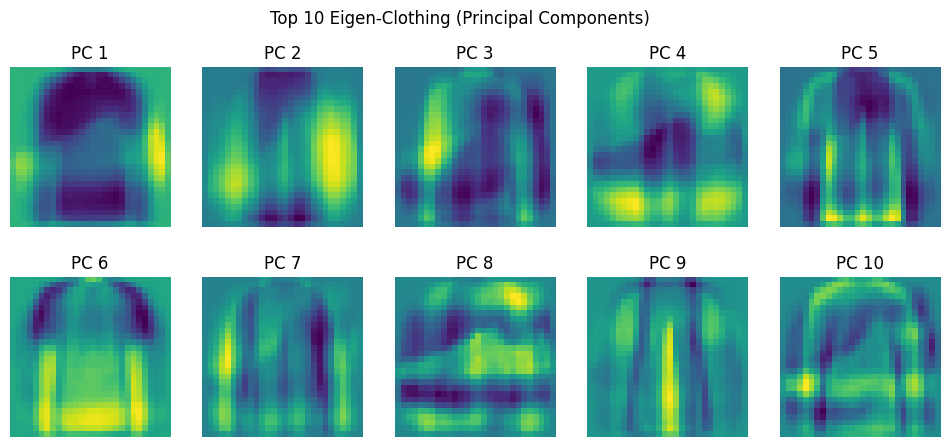

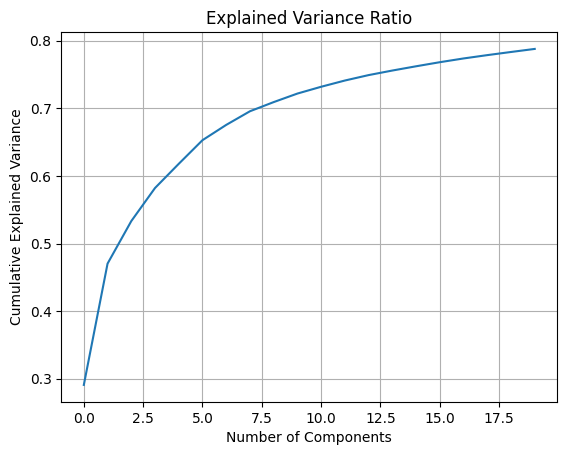

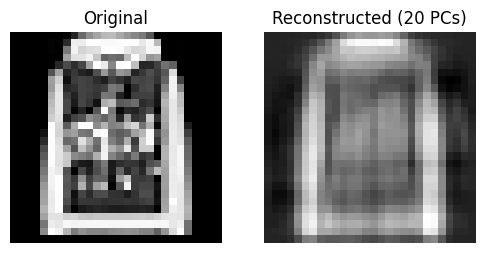


--- Running LDA (sklearn) ---


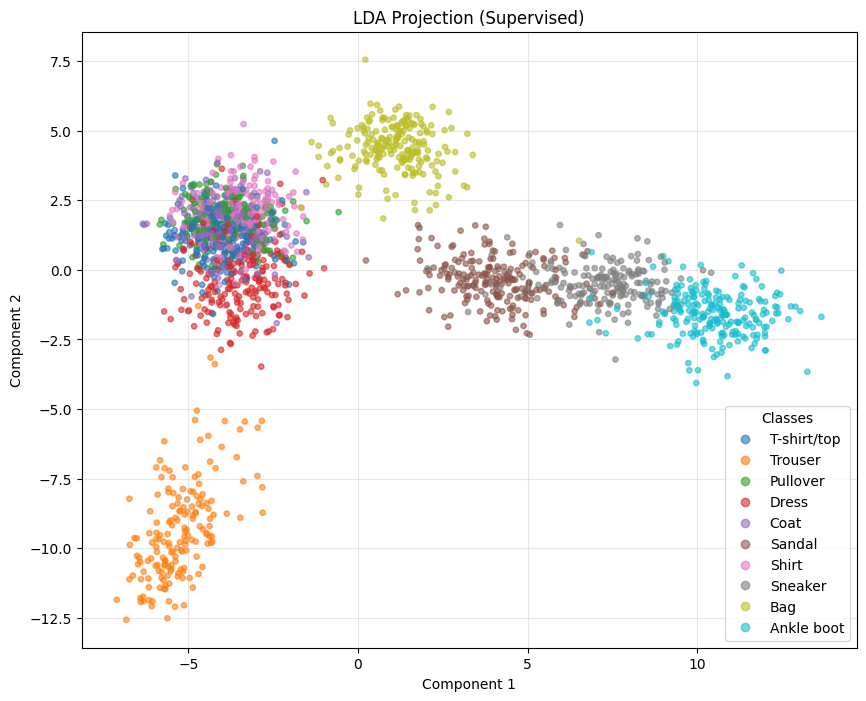

Done.


In [3]:
# ==========================================
# 1. STUDENT IMPLEMENTATION: PCA FROM SCRATCH
# ==========================================
class PCA_FromScratch:
    def __init__(self, n_components, solver='eigen'):
        self.n_components = n_components
        self.solver = solver
        self.components_ = None
        self.mean_ = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        """
        Fit the model with X.

        Tasks:
        1. Preprocess (center) the data
        2. If solver == 'eigen': compute covariance + eigendecomposition
        3. If solver == 'svd': do SVD without covariance
        4. Sort and keep top n_components
        """
        n_samples, n_features = X.shape

        # --- Preprocess: mean-center (standard PCA) ---
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_

        if self.solver == 'eigen':
            # Cov matrix C = (X^T X) / (n-1)
            cov_matrix = (X_centered.T @ X_centered) / (n_samples - 1)

            # Eigendecomposition (cov is symmetric -> use eigh)
            eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

            # Sort descending
            idx = np.argsort(eigenvalues)[::-1]
            eigenvalues = eigenvalues[idx]
            eigenvectors = eigenvectors[:, idx]

            # Store top n_components (as rows)
            self.components_ = eigenvectors[:, :self.n_components].T

            # Explained variance ratio
            total_var = np.sum(eigenvalues)
            self.explained_variance_ratio_ = eigenvalues[:self.n_components] / total_var

        elif self.solver == 'svd':
            # SVD on centered data (no covariance)
            U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

            # Components are rows of Vt
            self.components_ = Vt[:self.n_components, :]

            # Explained variance ratio:
            # eigenvalues of covariance = S^2 / (n-1)
            eigenvalues = (S ** 2) / (n_samples - 1)
            total_var = np.sum(eigenvalues)
            self.explained_variance_ratio_ = eigenvalues[:self.n_components] / total_var

        else:
            raise ValueError("solver must be either 'eigen' or 'svd'")

        return self

    def transform(self, X):
        """
        Project X onto the principal components.
        X_new = (X - mean) dot W^T
        """
        X_centered = X - self.mean_
        return X_centered @ self.components_.T

    def inverse_transform(self, X_transformed):
        """
        Reconstruct the original data from the projected data.
        X_recon = X_transformed dot W + mean
        """
        return (X_transformed @ self.components_) + self.mean_

# ==========================================
# 2. HELPER: VISUALIZATION TOOLS
# ==========================================
def plot_projection(X_proj, y, title):
    """Plots the 2D projection of the data."""
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_proj[:, 0], X_proj[:, 1], c=y, cmap='tab10', alpha=0.6, s=15)
    plt.legend(handles=scatter.legend_elements()[0],
               labels=[LABEL_MAP[i] for i in range(10)],
               title="Classes")
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_eigen_clothing(components):
    """Visualizes the top components as images."""
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle("Top 10 Eigen-Clothing (Principal Components)")
    for i, ax in enumerate(axes.flat):
        img = components[i].reshape(28, 28)
        ax.imshow(img, cmap='viridis')
        ax.axis('off')
        ax.set_title(f"PC {i+1}")
    plt.show()

# ==========================================
# 3. MAIN EXECUTION FLOW
# ==========================================
if __name__ == "__main__":
    # A. Load Data
    X, y = load_fashion_mnist_data(num_samples=2000)

    # --------------------------------------
    # B. Run Student PCA
    # --------------------------------------
    print("\n--- Running PCA From Scratch ---")
    pca = PCA_FromScratch(n_components=20, solver='eigen')  # or solver='svd'
    pca.fit(X)

    if pca.components_ is None:
        print("ERR: PCA fit method not implemented yet.")
    else:
        # 1. Transform to 2D for visualization
        X_pca_2d = pca.transform(X)[:, :2]
        plot_projection(X_pca_2d, y, "PCA Projection (Unsupervised)")

        # 2. Visualize the Eigen-clothing
        plot_eigen_clothing(pca.components_)

        # 3. Explained Variance Plot
        plt.plot(np.cumsum(pca.explained_variance_ratio_))
        plt.xlabel('Number of Components')
        plt.ylabel('Cumulative Explained Variance')
        plt.title('Explained Variance Ratio')
        plt.grid()
        plt.show()

        # 4. (Optional) Reconstruction demo using top 20 comps
        X_proj_20 = pca.transform(X)  # shape (N, 20)
        X_recon = pca.inverse_transform(X_proj_20)  # shape (N, 784)

        # Show one original vs reconstructed
        idx_show = 0
        plt.figure(figsize=(6, 3))
        plt.subplot(1, 2, 1)
        plt.imshow(X[idx_show].reshape(28, 28), cmap='gray')
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(X_recon[idx_show].reshape(28, 28), cmap='gray')
        plt.title("Reconstructed (20 PCs)")
        plt.axis("off")
        plt.show()

    # --------------------------------------
    # C. Run LDA (Comparison)
    # --------------------------------------
    print("\n--- Running LDA (sklearn) ---")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    lda = LDA(n_components=2)
    X_lda = lda.fit_transform(X_scaled, y)

    plot_projection(X_lda, y, "LDA Projection (Supervised)")

    print("Done.")



1.
Because LDA is supervised and explicitly chooses projection directions that maximize class separation. Concretely, LDA uses the labels to find directions that make between-class variance large while keeping within-class variance small (it optimizes a ratio like “scatter between classes / scatter within classes”). So points from different classes get pushed apart in the 2D space.

PCA is unsupervised and ignores labels. It finds directions that explain the most overall variance in the data, which in images often corresponds to things like brightness, strokes, or background/shape variations shared across many classes. High variance directions are not necessarily the ones that best separate categories, so different classes can still overlap heavily in the first two PCs.

2.
We don’t have labels (or labels are unreliable / not available yet). PCA works purely from
𝑋
X.

Our goal is compression / denoising / reconstruction (like your “reconstructed (20 PCs)” image): PCA preserves information/variance, which is great for dimensionality reduction before storage, visualization, or as preprocessing.

We want a general-purpose preprocessing step before different downstream tasks (e.g., clustering, anomaly detection), without baking in one specific set of class labels.

LDA constraints hurt: LDA can produce at most (number of classes − 1) components, and it can overfit when sample size is small relative to dimensionality (or when class distributions violate LDA’s assumptions).

### Part 2 : Non-linear Methods (5 points)
Goal: Understand how to preserve local structure versus global geometry in non-linear data.

**Task 2.1:** t-SNE (Stochastic Neighbor Embedding) (5 points)

- Implementation: Apply t-SNE using the sklearn library imported here, to the same subset.

- Experiment: Run t-SNE with three different Perplexity values : 5, 30, 100.

- Analysis Question: Explain the mathematical role of perplexity. How does the visualization change? Which algorithm (PCA, MDS, t-SNE) provides the best visual clustering of the classes?

Loading Fashion-MNIST via TensorFlow/Keras...
   > Subsetting to 1000 random samples...
   > Data Loaded. Shape: (1000, 784)

--- Running t-SNE Experiments ---
Running t-SNE with Perplexity = 5...
Running t-SNE with Perplexity = 30...
Running t-SNE with Perplexity = 100...


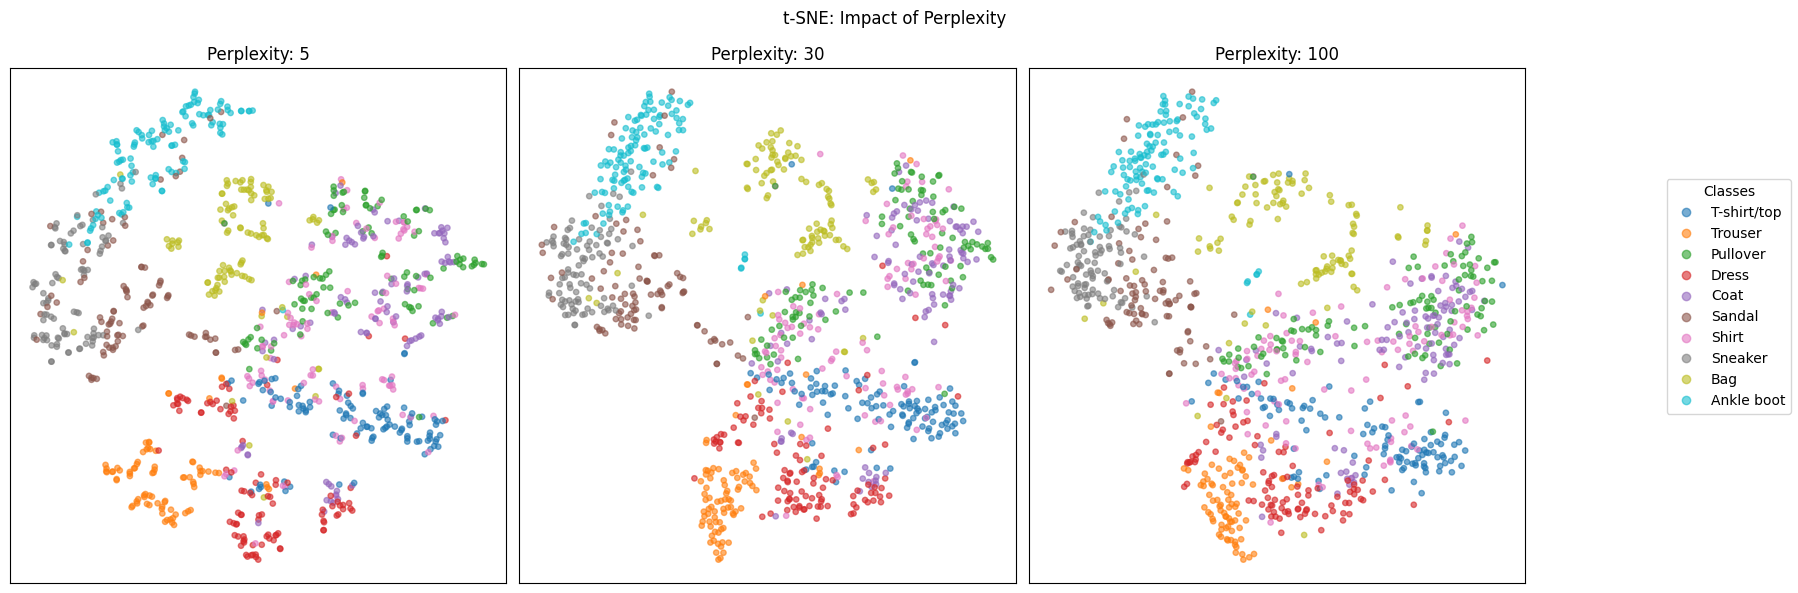

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS, TSNE
from sklearn.metrics import pairwise_distances

def run_tsne_experiment(X, y, perplexities=[5, 30, 100]):
    print(f"\n--- Running t-SNE Experiments ---")

    # (Optional but recommended) simple standardization w/o importing anything new
    X = X.astype(np.float32)
    X_mean = X.mean(axis=0, keepdims=True)
    X_std  = X.std(axis=0, keepdims=True) + 1e-8
    X_scaled = (X - X_mean) / X_std

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"t-SNE: Impact of Perplexity")

    for i, perp in enumerate(perplexities):
        print(f"Running t-SNE with Perplexity = {perp}...")

        # Initialize and Fit t-SNE to data
        tsne = TSNE(
            n_components=2,
            perplexity=perp,
            init="pca",
            learning_rate="auto",
            random_state=42
        )
        X_tsne = tsne.fit_transform(X_scaled)

        ax = axes[i]
        scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.6, s=15)
        ax.set_title(f"Perplexity: {perp}")
        ax.grid(True, alpha=0.3)
        ax.set_xticks([])
        ax.set_yticks([])

    handles, _ = scatter.legend_elements()
    labels = [LABEL_MAP[i] for i in range(10)]
    fig.legend(handles, labels, loc='center right', title="Classes")
    plt.tight_layout()
    plt.subplots_adjust(right=0.85)
    plt.show()

if __name__ == "__main__":
    X, y = load_fashion_mnist_data(num_samples=1000)
    run_tsne_experiment(X, y)


Perplexity = 5 (very local)
Produces many tight “islands” and can over-fragment classes into multiple small clusters. You often see clearer micro-clusters but less stable global layout.

Perplexity = 30 (balanced)
Typically gives the most interpretable tradeoff: clusters are still well separated, but classes look more coherent (fewer tiny disconnected bits).

Perplexity = 100 (more global)
Emphasizes larger-scale structure: clusters may merge or smear, and boundaries between visually similar classes (e.g., shirt/pullover/coat) can blur more. Global arrangement may look smoother, but local separations weaken.
PCA: linear, preserves global variance, often mixes classes in 2D.

MDS: tries to preserve pairwise distances globally; can help, but in high-dimensional noisy image spaces it usually doesn’t separate classes as cleanly as t-SNE.

t-SNE: best visual clustering (but note: distances between far-apart clusters are not very meaningful; it’s mainly for visualization, not faithful global geometry).

So: t-SNE provides the best visual clustering here.

### Part 3: Parts-Based Representation (NMF) (20 points)

Goal: Understand additive vs. subtractive feature learning.

**Task 3.1:** Non-Negative Matrix Factorization (10 points)

- Complete the preprocessing function load_non_negative_data()
- Initialize the NMF model (the required function has already been imported at top) and fit the model.
- Save the transformed data and the components (basis vectors).

- Visual: Visualize the components.

**Analysis Question:** (10 points)
1. Compare the visual components of NMF to the PCA "Eigen-clothing." How do these components differ?
2. Why is the non-negativity constraint crucial for "interpretable" machine learning?


--- Running NMF (NumPy) ---
Reconstruction Error (Frobenius): 208.1141


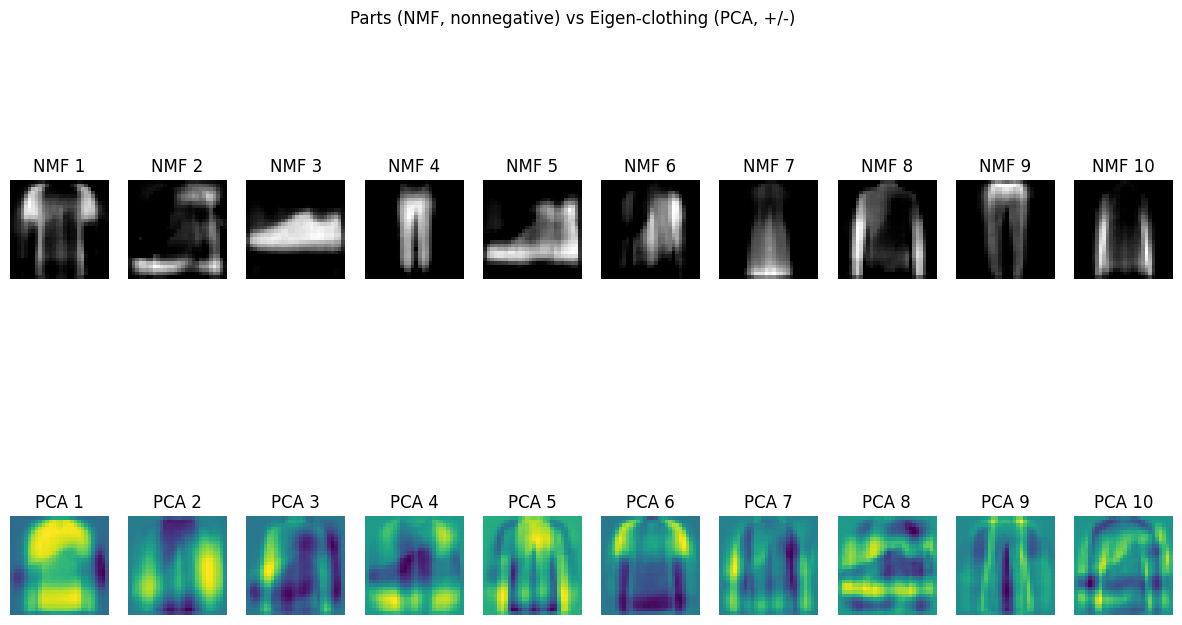

In [11]:
# =========================
# Part 3: NMF (NumPy-only, no new imports)
# =========================

LABEL_MAP = {
    0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
}

def load_fashion_mnist_data(num_samples=2000, seed=42):
    (x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
    X = np.concatenate([x_train, x_test]).reshape(-1, 784).astype(np.float32)
    y = np.concatenate([y_train, y_test]).astype(np.int64)

    if num_samples is not None and num_samples < X.shape[0]:
        rng = np.random.RandomState(seed)
        idx = rng.choice(X.shape[0], num_samples, replace=False)
        X, y = X[idx], y[idx]
    return X, y

def load_non_negative_data(n_samples=2000):
    """
    NMF requires X >= 0. Fashion-MNIST pixels are 0..255.
    Scale to [0,1] by dividing by 255 (no MinMaxScaler import).
    """
    X, y = load_fashion_mnist_data(num_samples=n_samples)
    X_scaled = X / 255.0
    return X_scaled, y

# ---------- PCA from scratch (SVD) for optional comparison ----------
class PCA_FromScratch:
    def __init__(self, n_components):
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None  # (k, D)

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_
        _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
        self.components_ = Vt[:self.n_components, :]
        return self

# ---------- NMF from scratch (multiplicative updates) ----------
def nmf_numpy(X, n_components=10, max_iter=200, seed=42, eps=1e-8):
    """
    Factorize X ≈ W @ H with X>=0, W>=0, H>=0 using multiplicative updates.
    X: (N, D), W: (N, k), H: (k, D)
    """
    rng = np.random.RandomState(seed)
    N, D = X.shape

    W = rng.rand(N, n_components).astype(np.float32)
    H = rng.rand(n_components, D).astype(np.float32)

    for _ in range(max_iter):
        # H update
        WH = (W.T @ W @ H) + eps
        H *= (W.T @ X) / WH

        # W update
        HHt = (H @ H.T) + eps
        W *= (X @ H.T) / ((W @ HHt) + eps)

    recon = W @ H
    err = np.linalg.norm(X - recon, ord='fro')
    return W, H, err

def plot_components_comparison(nmf_components, pca_components=None, title="Basis Vectors"):
    n_comp = nmf_components.shape[0]
    rows = 2 if pca_components is not None else 1

    plt.figure(figsize=(15, 4 * rows))

    # NMF row
    for i in range(n_comp):
        plt.subplot(rows, n_comp, i + 1)
        plt.imshow(nmf_components[i].reshape(28, 28), cmap='gray')
        plt.title(f"NMF {i+1}")
        plt.axis('off')

    # PCA row (optional)
    if pca_components is not None:
        for i in range(n_comp):
            plt.subplot(rows, n_comp, n_comp + i + 1)
            plt.imshow(pca_components[i].reshape(28, 28), cmap='viridis')
            plt.title(f"PCA {i+1}")
            plt.axis('off')

    plt.suptitle(title)
    plt.show()

# =========================
# RUN Part 3
# =========================
X_pos, y = load_non_negative_data(n_samples=2000)

print("\n--- Running NMF (NumPy) ---")
W, H, err = nmf_numpy(X_pos, n_components=10, max_iter=200)
print(f"Reconstruction Error (Frobenius): {err:.4f}")

# Optional PCA comparison (top 10 components)
pca = PCA_FromScratch(n_components=10).fit(X_pos)
plot_components_comparison(H, pca_components=pca.components_,
                           title="Parts (NMF, nonnegative) vs Eigen-clothing (PCA, +/-)")


1.
In the figure, the NMF components look like actual clothing parts / prototypes (e.g., a boot/shoe shape, pants-like vertical legs, a shirt torso). They are localized and additive: each component is a nonnegative “piece” that can be combined to build an image.

The PCA components look more like global templates with positive and negative patterns (the viridis colors show +/–). They often appear holistic and wave-like, spreading across the whole image and encoding “directions of variation” (e.g., brighten sleeves while darkening the center). So PCA components are not “parts,” but contrast patterns that can add or subtract from the mean image.

2.

In PCA, coefficients can be negative, so components can cancel each other (add some pixels, subtract others). That cancellation makes features harder to interpret physically—especially for images—since “negative sleeve” or “subtracting pixels” is not a natural parts-based explanation.

###Part 4: The Clustering Challenge (15 points)
Goal : Analyze how dimensionality reduction impacts clustering performance. We will use two metrics to evaluate the output clusters, which have already been implemented in the code below. These are described briefly below,
- **The Silhouette Score** : It measures how similar a data point is to its own cluster (cohesion) compared to other clusters (separation). It does not require the true labels (ground truth), making it perfect for real-world unsupervised learning. For a single sample $i$, it is defined as, $$s(i) = \frac{b(i) - a(i)}{\max(a(i),b(i))} $$ where $a(i)$ is the average distance between sample $i$ and all other samples in the same cluster and $b(i)$ is the average distance between sample $i$ and all samples in the nearest neighboring cluster. You are encouraged to read more details at : https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

- **The Purity Score** : It is an external evaluation metric, meaning it requires the ground truth labels to calculate. It measures the extent to which a cluster contains a single class. It is defined as,
$$ \text{Purity} = \frac{1}{N} \sum_{k \in \text{clusters}} \max_{j \in \text{Classes}} \mid C_k \cap L_j \mid $$
where $C_k$ is a cluster, and $L_j$ is the set of points with label $j$. For more details, you can refer : https://nlp.stanford.edu/IR-book/html/htmledition/evaluation-of-clustering-1.html

**Task 4.1:** The Baseline (K-Means) (5 points)

- Run K-Means (k=10) on the raw pixel data (784 dimensions). You can use the KMeans implementation imported from sklearn.cluster in the cell below.
- Report the Silhouette Score and Purity Score (using ground truth labels for validation only).

**Task 4.2:** The Curse of Dimensionality (5 points)

- Run K-Means on the PCA-reduced data (e.g., top 20 components).

-  Compare the clustering performance (in terms of Silhouette and Purity scores) of Raw vs. PCA data. Did the performance improve or degrade? Explain in no more than one or two lines why.


**Task 4.3:** Soft vs. Hierarchical (5 points)

- Fit a GMM on the PCA-reduced data. You can use the GaussianMixture implementation imported from sklearn.cluster in the cell below.
- Does the purity improve over K-means? Explain your observation in no more than 1-2 lines.
- Visualize the probability distribution of a specific "ambiguous" image (e.g., a sneaker that looks like a boot). Show the soft assignment probabilities.

Loading Fashion-MNIST via TensorFlow/Keras...
   > Subsetting to 2000 random samples...
   > Data Loaded. Shape: (2000, 784)

--- Task 4.1 & 4.2: K-Means Clustering ---
1. Running K-Means on Raw Data (784 dimensions)...
   Raw Data -> Silhouette: 0.1367 | Purity: 0.5275
2. Running K-Means on PCA Reduced Data (20 dimensions)...
   PCA Data -> Silhouette: 0.2345 | Purity: 0.5380

--- Task 4.3: Gaussian Mixture Models (Soft Clustering) ---
   GMM Purity: 0.5520
   Most ambiguous sample index: 759
   True label: 0 (T-shirt/top)
   Max cluster prob: 0.5214
   Top-3 cluster probs (cluster_id, prob):
     (5, 0.5214)
     (3, 0.4785)
     (0, 0.0001)


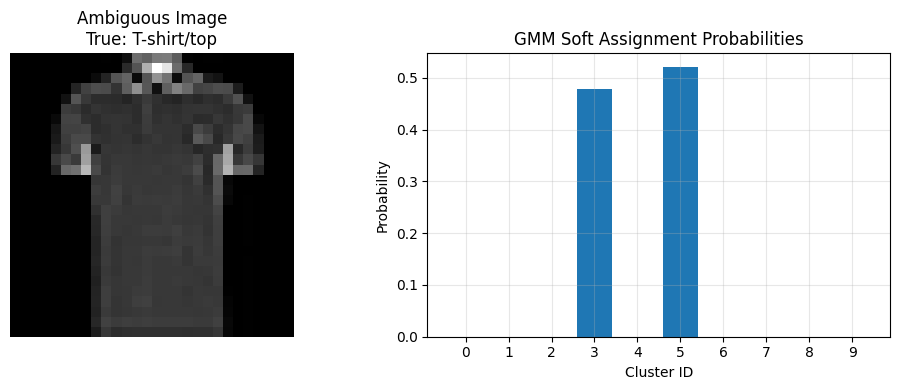

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, confusion_matrix
from scipy.cluster.hierarchy import dendrogram, linkage

def load_data(num_samples=2000):
    print(f"Loading Fashion-MNIST (N={num_samples})...")
    X, y = load_fashion_mnist_data(num_samples)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, y, X  # return original X too (for image display)

def compute_purity(y_true, y_pred):
    """
    Computes clustering purity.
    Purity = (1/N) * sum(max(intersection(cluster_i, class_j)))
    """
    cm = confusion_matrix(y_true, y_pred)
    return np.sum(np.amax(cm, axis=0)) / np.sum(cm)

# ---------- Simple PCA via NumPy SVD (no new imports) ----------
def pca_reduce_numpy(X, n_components=20):
    """
    PCA using SVD on mean-centered data.
    Returns:
      X_pca: (N, n_components)
      mean:  (D,)
      components: (n_components, D)  (rows are principal directions)
    """
    mean = np.mean(X, axis=0)
    X_centered = X - mean
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    components = Vt[:n_components, :]                  # (k, D)
    X_pca = X_centered @ components.T                  # (N, k)
    return X_pca, mean, components

# ==========================================
# K-MEANS (RAW vs PCA)
# ==========================================
def run_kmeans_experiment(X_pixels, y_true):
    print("\n--- Task 4.1 & 4.2: K-Means Clustering ---")

    # Scale once (KMeans + silhouette are distance-based)
    scaler = StandardScaler()
    X_raw = scaler.fit_transform(X_pixels)

    # A. Run K-Means on RAW Data (High Dimensionality)
    print("1. Running K-Means on Raw Data (784 dimensions)...")

    kmeans_raw = KMeans(n_clusters=10, random_state=42, n_init=10)
    raw_labels = kmeans_raw.fit_predict(X_raw)

    raw_sil = silhouette_score(X_raw, raw_labels)
    raw_pur = compute_purity(y_true, raw_labels)
    print(f"   Raw Data -> Silhouette: {raw_sil:.4f} | Purity: {raw_pur:.4f}")

    # B. Run K-Means on PCA Data (Reduced Dimensionality)
    print("2. Running K-Means on PCA Reduced Data (20 dimensions)...")

    # PCA reduce to 20 dims (on scaled data)
    X_pca, pca_mean, pca_components = pca_reduce_numpy(X_raw, n_components=20)

    kmeans_pca = KMeans(n_clusters=10, random_state=42, n_init=10)
    pca_labels = kmeans_pca.fit_predict(X_pca)

    pca_sil = silhouette_score(X_pca, pca_labels)
    pca_pur = compute_purity(y_true, pca_labels)
    print(f"   PCA Data -> Silhouette: {pca_sil:.4f} | Purity: {pca_pur:.4f}")

    # Return PCA data + info for GMM + original pixels for visualization
    pca_info = {"mean": pca_mean, "components": pca_components}
    return X_pca, pca_info, X_pixels

# ==========================================
# SOFT CLUSTERING (GMM)
# ==========================================
def run_gmm_experiment(X_pca, y_true, X_pixels=None):
    print("\n--- Task 4.3: Gaussian Mixture Models (Soft Clustering) ---")

    gmm = GaussianMixture(n_components=10, covariance_type='full', random_state=42)
    gmm.fit(X_pca)

    # HARD labels (for purity comparison)
    gmm_labels = gmm.predict(X_pca)
    print(f"   GMM Purity: {compute_purity(y_true, gmm_labels):.4f}")

    # SOFT probabilities
    probs = gmm.predict_proba(X_pca)  # (N, 10)

    # Find a sample where model is most uncertain: smallest max prob
    maxp = probs.max(axis=1)
    idx_uncertain = int(np.argmin(maxp))

    print(f"   Most ambiguous sample index: {idx_uncertain}")
    print(f"   True label: {y_true[idx_uncertain]} ({LABEL_MAP[int(y_true[idx_uncertain])]})")
    print(f"   Max cluster prob: {maxp[idx_uncertain]:.4f}")
    print("   Top-3 cluster probs (cluster_id, prob):")
    top3 = np.argsort(probs[idx_uncertain])[::-1][:3]
    for cid in top3:
        print(f"     ({cid}, {probs[idx_uncertain, cid]:.4f})")

    # Visualize ambiguous image + probability distribution
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    if X_pixels is not None:
        plt.imshow(X_pixels[idx_uncertain].reshape(28, 28), cmap="gray")
        plt.title(f"Ambiguous Image\nTrue: {LABEL_MAP[int(y_true[idx_uncertain])]}")
        plt.axis("off")
    else:
        plt.title("Ambiguous sample (image not provided)")
        plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.bar(np.arange(probs.shape[1]), probs[idx_uncertain])
    plt.title("GMM Soft Assignment Probabilities")
    plt.xlabel("Cluster ID")
    plt.ylabel("Probability")
    plt.xticks(np.arange(probs.shape[1]))
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==========================================
# MAIN
# ==========================================
if __name__ == "__main__":
    # use your provided loader
    X, y = load_fashion_mnist_data(num_samples=2000)

    # 1. K-Means (Raw vs PCA)
    X_pca, pca_info, X_pixels = run_kmeans_experiment(X, y)

    # 2. GMM (Soft Clustering)
    if X_pca is not None:
        run_gmm_experiment(X_pca, y, X_pixels=X_pixels)
    else:
        print("Complete Task 4.1 to generate X_pca for the next steps.")


Task 4.1 vs 4.2 (Raw vs PCA) — did performance improve?

Yes, PCA improved clustering.

Raw (784D): Silhouette 0.1367, Purity 0.5275

PCA (20D): Silhouette 0.2345, Purity 0.5380

Why (1–2 lines): PCA removes noise/redundant pixel dimensions and keeps the most informative variance, making distances more meaningful and clusters tighter, so K-Means separates groups better.
Task 4.3 (GMM vs K-Means) — does purity improve?

Yes. GMM purity = 0.5520, which is higher than K-Means on PCA (0.5380).

Why (1–2 lines): GMM can model clusters with different shapes and gives soft assignments, so it handles overlapping/ambiguous classes better than K-Means’ hard, spherical-cluster assumption.
Most ambiguous sample (index 759, true label T-shirt/top), the model’s highest cluster probability is only 0.5214, and the second is 0.4785.

This means the point lies near the boundary between two mixture components, so GMM is uncertain and splits its belief across two clusters—exactly what “soft clustering” is supposed to show.

### Part 5: The Deep Learning Approach (Autoencoders) (30 points)

Goal: Compare linear compression (PCA) with non-linear neural compression.

**Task 5.1:** Build a Stacked Autoencoder (15 points) \
Here you will code a neural network using PyTorch and train it to be an Image Autoencoder. After defining the components of your neural network you will train it to reconstruct the input image by minimizing the pixel-level loss between the input and reconstructed images.

The architecture for your neural network is specified as follows,
1. **Input Layer:**

    Size: 784 neurons (representing the 28×28 flattened image).

2. **Encoder Hidden Layer:**

    Operation: Fully Connected (Linear).

    Transformation: 784 to 128.

    Activation: ReLU (Rectified Linear Unit).

3. **Latent Layer (z - The Bottleneck):**

    Operation: Fully Connected (Linear).

    Transformation: 128 to 32.

    Activation: ReLU.

4. **Decoder Hidden Layer:**

    Operation: Fully Connected (Linear).

    Transformation: 32 to 128.

    Activation: ReLU.

5. **Output Layer:**

    Operation: Fully Connected (Linear).

    Transformation: 128 to 784.

    Activation: Sigmoid.

*Note : We use Sigmoid here because our input data is normalized to the range [0,1]. The Sigmoid function forces the network output to strictly stay within this range.*

*Note: Here, “transformation” means the input vector size is mapped to a new output vector size.*

- Complete the load_data_and_fit_pca() function to return a PCA model fit on the training data.
- Design a fully-connected neural network with the specificiation provided above. Complete the definitions of different components in the Autoencoder class.

- Implement the forward pass by completing the forward() method.
- Complete the training loop and train on the dataset using Mean Squared Error (MSE) loss. The neural network will be trained to reconstruct the input image using this pixel-level loss function.

**Task 5.2:** Reconstruction Battle (10 points)

Take 5 test images and show:

- Original Image.

- PCA Reconstruction (using 32 components).

- Autoencoder Reconstruction (using 32 latent neurons).

**Analysis Question:** (5 points)
Which method preserves sharper details? Why?

Using device: cpu
Loading Fashion-MNIST via Keras...
Fitting PCA with n_components=32...
Starting Training...
Epoch 1/10 | Loss: 0.0318
Epoch 2/10 | Loss: 0.0184
Epoch 3/10 | Loss: 0.0161
Epoch 4/10 | Loss: 0.0148
Epoch 5/10 | Loss: 0.0140
Epoch 6/10 | Loss: 0.0133
Epoch 7/10 | Loss: 0.0129
Epoch 8/10 | Loss: 0.0125
Epoch 9/10 | Loss: 0.0122
Epoch 10/10 | Loss: 0.0120

Generating Comparison Plots...


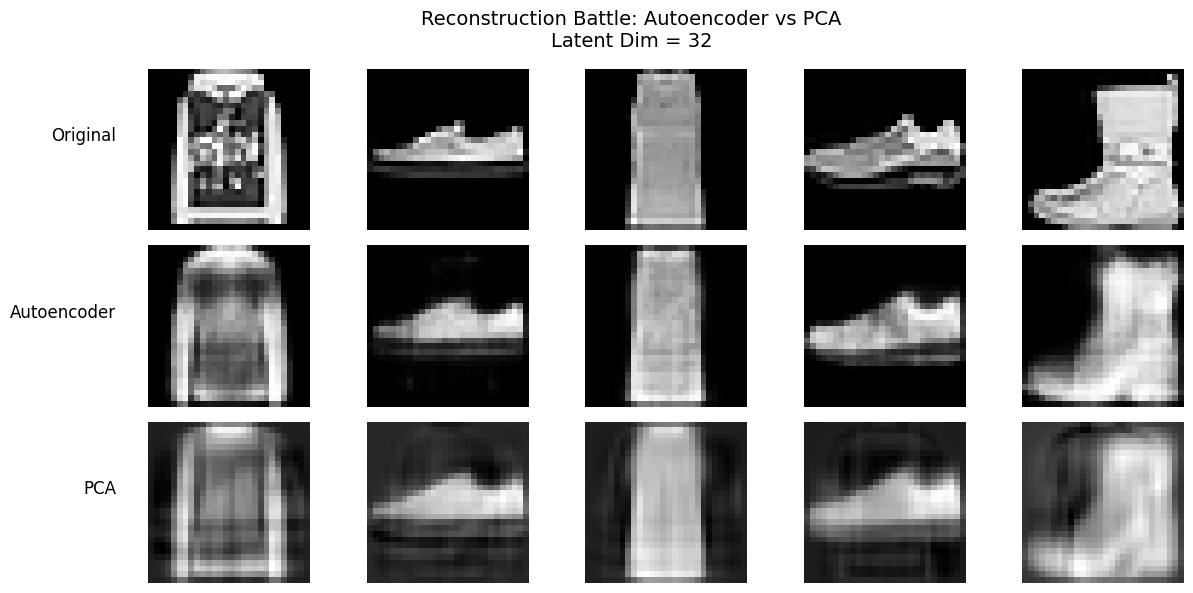

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# 0. CONFIGURATION
# ==========================================
BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 10
LATENT_DIM = 32  # The bottleneck size

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. PCA (NumPy SVD) — no extra imports needed
# ==========================================
class PCA_Numpy:
    def __init__(self, n_components):
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None  # shape (k, D)

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_
        _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
        self.components_ = Vt[:self.n_components, :]
        return self

    def transform(self, X):
        Xc = X - self.mean_
        return Xc @ self.components_.T

    def inverse_transform(self, Z):
        return (Z @ self.components_) + self.mean_

# ==========================================
# 1. DATA PREPARATION
# ==========================================
def load_data_and_fit_pca():
    """
    Loads data, scales it, fits PCA, and prepares PyTorch loaders.
    """
    print("Loading Fashion-MNIST via Keras...")
    (x_train_raw, _), (x_test_raw, _) = fashion_mnist.load_data()

    # Concatenate and flatten
    X = np.concatenate([x_train_raw, x_test_raw])
    X = X.reshape(X.shape[0], -1)  # (70000, 784)

    # Scale to [0, 1]
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # Split
    X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

    # --- PCA SETUP ---
    print(f"Fitting PCA with n_components={LATENT_DIM}...")
    pca = PCA_Numpy(n_components=LATENT_DIM)
    pca.fit(X_train)  # Fit PCA model only on training data

    # --- PYTORCH SETUP ---
    tensor_train = torch.FloatTensor(X_train)
    tensor_test = torch.FloatTensor(X_test)

    train_loader = torch.utils.data.DataLoader(tensor_train, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = torch.utils.data.DataLoader(tensor_test, batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, test_loader, pca

# ==========================================
# 2. AUTOENCODER MODEL
# ==========================================
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder: 784 -> 128 -> 32
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, LATENT_DIM),
            nn.ReLU()
        )

        # Decoder: 32 -> 128 -> 784 (Sigmoid at end)
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

# ==========================================
# 3. TRAINING LOOP
# ==========================================
def train_model(model, train_loader):
    model.to(device)
    model.train()

    criterion = nn.MSELoss()  # Define the loss fn
    optimizer = optim.Adam(model.parameters(), lr=LR)

    print("Starting Training...")
    for epoch in range(EPOCHS):
        total_loss = 0.0

        for batch in train_loader:
            batch = batch.to(device)

            # Forward pass
            reconstruction = model(batch)

            # Compute Loss
            loss = criterion(reconstruction, batch)

            # Backward + step
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f}")

# ==========================================
# 4. VISUALIZATION
# ==========================================
def visualize_comparison(ae_model, pca_model, test_loader):
    print("\nGenerating Comparison Plots...")
    ae_model.to(device)
    ae_model.eval()

    # Get one batch of test images
    data_iter = iter(test_loader)
    images_tensor = next(data_iter)  # Shape: [B, 784]

    # Autoencoder reconstruction
    with torch.no_grad():
        images_device = images_tensor.to(device)
        recon_ae = ae_model(images_device).cpu().numpy()

    # PCA reconstruction
    images_np = images_tensor.numpy()
    pca_encoded = pca_model.transform(images_np)
    recon_pca = pca_model.inverse_transform(pca_encoded)

    # Plotting (Task says 5 images; you can change to 8 if you want)
    n_samples = 5
    fig, axes = plt.subplots(3, n_samples, figsize=(12, 6))
    plt.suptitle(
        f"Reconstruction Battle: Autoencoder vs PCA\nLatent Dim = {LATENT_DIM}",
        fontsize=14
    )

    rows = ["Original", "Autoencoder", "PCA"]

    for i in range(n_samples):
        axes[0, i].imshow(images_np[i].reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')

        axes[1, i].imshow(recon_ae[i].reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')

        axes[2, i].imshow(recon_pca[i].reshape(28, 28), cmap='gray')
        axes[2, i].axis('off')

    for ax, row_name in zip(axes[:, 0], rows):
        ax.set_title(row_name, fontsize=12, x=-0.2, y=0.5, ha='right')

    plt.tight_layout()
    plt.show()

# ==========================================
# MAIN
# ==========================================
if __name__ == "__main__":
    train_loader, test_loader, pca_model = load_data_and_fit_pca()

    ae_model = Autoencoder()
    train_model(ae_model, train_loader)

    visualize_comparison(ae_model, pca_model, test_loader)


n the shoe/boot examples, the autoencoder keeps the outline and sole shape more clearly, while PCA looks more washed-out and smeared (strong blur + faint “ghosting” bands).

In the bag/top, PCA introduces more global blurring and blocky artifacts, while the autoencoder keeps a cleaner overall silhouette.

PCA is a linear low-rank approximation that uses a single set of global directions to minimize squared error across all images, so fine edges get averaged out → blur. The autoencoder learns a nonlinear encoding/decoding specialized to Fashion-MNIST, so it can represent curved/complex structures with the same 32-dimensional bottleneck and reconstruct edges/silhouettes more faithfully.

In [13]:

import numpy as np

# Nodes and function
x = np.array([0.0, 0.5, 1.0])
f = np.exp(3*x)  # [1, e^{3/2}, e^3]

# Newton basis q0=1, q1=(x-x0), q2=(x-x0)(x-x1)
def q0(t): return 1.0
def q1(t): return (t - x[0])
def q2(t): return (t - x[0])*(t - x[1])

# Build A_{ik} = q_k(x_i)
A = np.array([
    [q0(x[0]), q1(x[0]), q2(x[0])],
    [q0(x[1]), q1(x[1]), q2(x[1])],
    [q0(x[2]), q1(x[2]), q2(x[2])]
], dtype=float)

alpha = np.linalg.solve(A, f)

print("A=\n", A)
print("f=\n", f)
print("alpha=\n", alpha)   # [alpha0, alpha1, alpha2]


A=
 [[ 1.   0.  -0. ]
 [ 1.   0.5  0. ]
 [ 1.   1.   0.5]]
f=
 [ 1.          4.48168907 20.08553692]
alpha=
 [ 1.          6.96337814 24.24431757]
